# AI Applications for Dyslexic Students
## Personalized Learning Content Recommendation - Full ML Pipeline

| Step | Description |
|------|-------------|
| 1 | Dataset Loading |
| 2 | Data Exploration |
| 3 | Data Cleaning |
| 4 | Exploratory Data Analysis |
| 5 | Feature Selection (Filter, Wrapper, Embedded, Lasso) |
| 6 | Model Training (LR, RF, SVM, NN, XGBoost, LightGBM, CatBoost, GBM) |
| 7 | Model Evaluation (Accuracy, RMSE, MAE, R2, ROC-AUC, F-Value) |
| 8 | Confusion Matrices & ROC Curves |
| 9 | Comparison Table & Feature Importance |

Dataset: https://www.kaggle.com/datasets/luzrello/dyslexia

## 1. Import Libraries

In [34]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_absolute_error, r2_score, f1_score,
    roc_auc_score, roc_curve, auc
)
from sklearn.feature_selection import (
    SelectKBest, f_classif, RFE, SelectFromModel
)
from sklearn.inspection import permutation_importance
from sklearn.multiclass import OneVsRestClassifier
from imblearn.over_sampling import SMOTE

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

print('All libraries imported successfully')

All libraries imported successfully


## 2. Dataset Loading

In [35]:
DATASET_PATH = 'dyslexia.csv'

if os.path.exists(DATASET_PATH):
    df = pd.read_csv(DATASET_PATH)
    print('Real dataset loaded')
else:
    print('Real dataset not found. Generating synthetic dataset...')

    np.random.seed(42)
    n = 500

    age              = np.random.randint(6, 18, n)
    gender           = np.random.choice(['Male', 'Female'], n)
    nativelang       = np.random.choice(['Yes', 'No'], n, p=[0.7, 0.3])
    otherlang        = np.random.choice(['Yes', 'No'], n, p=[0.4, 0.6])
    memory_score     = np.round(np.random.uniform(2, 10, n), 1)
    speed_score      = np.round(np.random.uniform(1, 10, n), 1)
    visual_score     = np.round(np.random.uniform(1, 10, n), 1)
    audio_score      = np.round(np.random.uniform(1, 10, n), 1)
    reading_ability  = np.round(np.random.uniform(1, 10, n), 1)
    spelling_ability = np.round(np.random.uniform(1, 10, n), 1)
    attention_score  = np.round(np.random.uniform(1, 10, n), 1)

    risk_score = -(reading_ability * 0.4 + spelling_ability * 0.3 +
                   memory_score * 0.2 + speed_score * 0.1) + np.random.normal(4, 1, n)
    dyslexia_risk = (risk_score > np.percentile(risk_score, 40)).astype(int)

    combined = reading_ability + memory_score + attention_score
    content_rec = pd.cut(
        combined,
        bins=[0, 12, 18, 24, 31],
        labels=['Intensive_Support', 'Basic_Learning', 'Standard_Learning', 'Advanced_Learning']
    )

    df = pd.DataFrame({
        'Age': age, 'Gender': gender, 'NativeLang': nativelang, 'OtherLang': otherlang,
        'Memory_Score': memory_score, 'Speed_Score': speed_score,
        'Visual_Score': visual_score, 'Audio_Score': audio_score,
        'Reading_Ability': reading_ability, 'Spelling_Ability': spelling_ability,
        'Attention_Score': attention_score, 'Dyslexia_Risk': dyslexia_risk,
        'Content_Recommendation': content_rec
    })

    df.to_csv('dyslexia_synthetic.csv', index=False)
    print('Synthetic dataset created with 500 students')

print(f'Dataset Shape: {df.shape}')
df.head(10)

Real dataset not found. Generating synthetic dataset...
Synthetic dataset created with 500 students
Dataset Shape: (500, 13)


,Age,Gender,NativeLang,OtherLang,Memory_Score,Speed_Score,Visual_Score,Audio_Score,Reading_Ability,Spelling_Ability,Attention_Score,Dyslexia_Risk,Content_Recommendation
0,12,Female,Yes,No,6.8,8.2,6.0,1.5,7.3,6.9,4.0,0,Standard_Learning
1,9,Female,Yes,No,7.4,4.3,6.7,6.6,4.7,2.9,1.5,1,Basic_Learning
2,16,Female,Yes,No,5.5,5.1,5.7,4.5,5.6,2.1,2.6,1,Basic_Learning
3,13,Female,Yes,Yes,5.6,4.6,5.2,9.4,9.1,7.3,9.7,0,Advanced_Learning
4,10,Male,Yes,No,7.8,1.8,3.1,5.9,9.0,2.0,4.9,0,Standard_Learning
5,12,Female,Yes,No,2.1,5.0,3.7,9.5,8.4,10.0,6.7,0,Basic_Learning
6,15,Female,Yes,Yes,4.7,2.8,3.6,3.0,5.6,2.7,7.5,0,Basic_Learning
7,8,Female,Yes,No,8.5,2.7,6.1,7.5,7.6,6.3,4.3,0,Standard_Learning
8,12,Female,Yes,Yes,6.8,1.8,2.1,6.6,5.6,4.7,2.3,1,Basic_Learning
9,16,Female,No,Yes,4.7,4.2,9.3,7.7,8.8,2.1,2.9,1,Basic_Learning


## 3. Data Exploration

In [36]:
print('=' * 50)
print('DATASET OVERVIEW')
print('=' * 50)
print(f'Rows    : {df.shape[0]}')
print(f'Columns : {df.shape[1]}')
print()
print('Column Data Types')
print(df.dtypes)
print()
print('Missing Values')
print(df.isnull().sum())

DATASET OVERVIEW
Rows    : 500
Columns : 13

Column Data Types
Age                          int32
Gender                         str
NativeLang                     str
OtherLang                      str
Memory_Score               float64
Speed_Score                float64
Visual_Score               float64
Audio_Score                float64
Reading_Ability            float64
Spelling_Ability           float64
Attention_Score            float64
Dyslexia_Risk                int64
Content_Recommendation    category
dtype: object

Missing Values
Age                       0
Gender                    0
NativeLang                0
OtherLang                 0
Memory_Score              0
Speed_Score               0
Visual_Score              0
Audio_Score               0
Reading_Ability           0
Spelling_Ability          0
Attention_Score           0
Dyslexia_Risk             0
Content_Recommendation    0
dtype: int64


In [37]:
print('Statistical Summary')
df.describe(include='all').round(2)

Statistical Summary


,Age,Gender,NativeLang,OtherLang,Memory_Score,Speed_Score,Visual_Score,Audio_Score,Reading_Ability,Spelling_Ability,Attention_Score,Dyslexia_Risk,Content_Recommendation
count,500.00,500,500,500,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500
unique,NaN,2,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,Male,Yes,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Basic_Learning
freq,NaN,259,345,308,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,233
mean,11.50,NaN,NaN,NaN,5.90,5.46,5.64,5.67,5.37,5.36,5.54,0.60,NaN
std,3.54,NaN,NaN,NaN,2.29,2.65,2.59,2.54,2.58,2.62,2.55,0.49,NaN
min,6.00,NaN,NaN,NaN,2.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,NaN
25%,8.00,NaN,NaN,NaN,3.80,3.10,3.40,3.70,3.20,3.00,3.30,0.00,NaN
50%,12.00,NaN,NaN,NaN,5.90,5.40,5.80,5.75,5.35,5.30,5.60,1.00,NaN
75%,15.00,NaN,NaN,NaN,7.90,7.72,7.90,7.82,7.70,7.60,7.70,1.00,NaN


In [38]:
print('Target Class Distribution - Content Recommendation')
print(df['Content_Recommendation'].value_counts())
print()
print('Dyslexia Risk Distribution')
print(df['Dyslexia_Risk'].value_counts())

Target Class Distribution - Content Recommendation
Content_Recommendation
Basic_Learning       233
Standard_Learning    167
Intensive_Support     76
Advanced_Learning     24
Name: count, dtype: int64

Dyslexia Risk Distribution
Dyslexia_Risk
1    300
0    200
Name: count, dtype: int64


## 4. Data Cleaning

In [39]:
df_clean = df.copy()

num_cols = df_clean.select_dtypes(include=[np.number]).columns
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns

for col in num_cols:
    missing = df_clean[col].isnull().sum()
    if missing > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
        print(f'Filled {missing} missing values in {col} with median')

for col in cat_cols:
    missing = df_clean[col].isnull().sum()
    if missing > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
        print(f'Filled {missing} missing values in {col} with mode')

print(f'Missing values after cleaning: {df_clean.isnull().sum().sum()}')

Missing values after cleaning: 0


In [40]:
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
after = len(df_clean)
print(f'Removed {before - after} duplicate rows. Rows remaining: {after}')

Removed 0 duplicate rows. Rows remaining: 500


In [41]:
print('Outlier Detection using IQR Method')
score_cols = [c for c in num_cols if c not in ['Age', 'Dyslexia_Risk']]

for col in score_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df_clean[col] < Q1 - 1.5 * IQR) | (df_clean[col] > Q3 + 1.5 * IQR)).sum()
    if outliers > 0:
        df_clean[col] = df_clean[col].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)
        print(f'{col}: {outliers} outliers capped')
    else:
        print(f'{col}: No outliers found')

Outlier Detection using IQR Method
Memory_Score: No outliers found
Speed_Score: No outliers found
Visual_Score: No outliers found
Audio_Score: No outliers found
Reading_Ability: No outliers found
Spelling_Ability: No outliers found
Attention_Score: No outliers found


In [42]:
le = LabelEncoder()

for col in ['Gender', 'NativeLang', 'OtherLang']:
    if col in df_clean.columns:
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))
        print(f'Encoded: {col}')

df_clean['Content_Recommendation'] = le.fit_transform(df_clean['Content_Recommendation'].astype(str))
label_classes = le.classes_
print(f'Target labels: {list(label_classes)}')
print('0=Advanced_Learning, 1=Basic_Learning, 2=Intensive_Support, 3=Standard_Learning')
df_clean.head()

Encoded: Gender
Encoded: NativeLang
Encoded: OtherLang
Target labels: ['Advanced_Learning', 'Basic_Learning', 'Intensive_Support', 'Standard_Learning']
0=Advanced_Learning, 1=Basic_Learning, 2=Intensive_Support, 3=Standard_Learning


,Age,Gender,NativeLang,OtherLang,Memory_Score,Speed_Score,Visual_Score,Audio_Score,Reading_Ability,Spelling_Ability,Attention_Score,Dyslexia_Risk,Content_Recommendation
0,12,0,1,0,6.8,8.2,6.0,1.5,7.3,6.9,4.0,0,3
1,9,0,1,0,7.4,4.3,6.7,6.6,4.7,2.9,1.5,1,1
2,16,0,1,0,5.5,5.1,5.7,4.5,5.6,2.1,2.6,1,1
3,13,0,1,1,5.6,4.6,5.2,9.4,9.1,7.3,9.7,0,0
4,10,1,1,0,7.8,1.8,3.1,5.9,9.0,2.0,4.9,0,3


## 5. Exploratory Data Analysis (EDA)

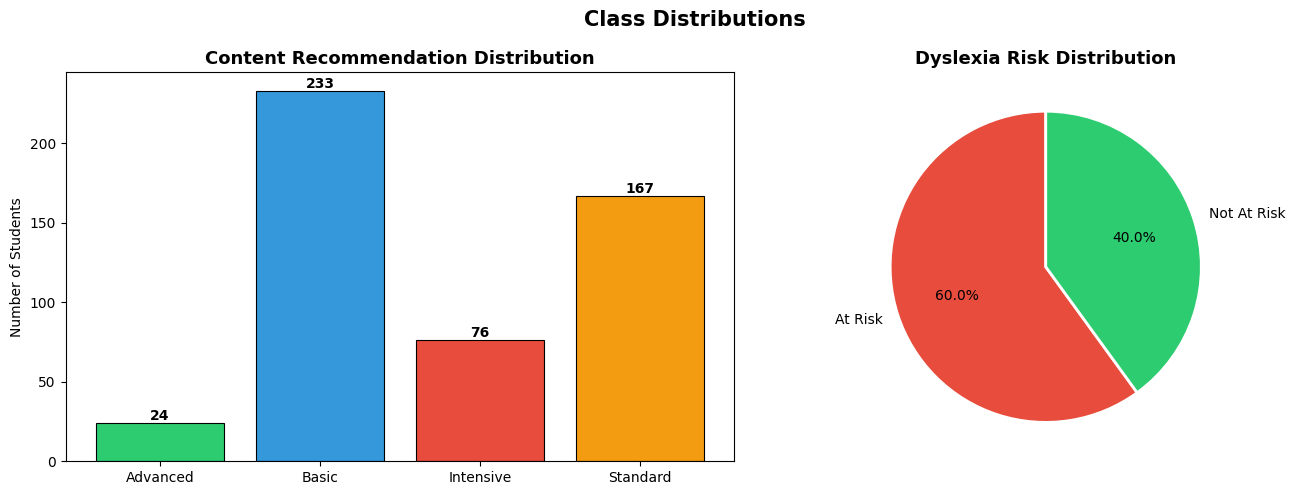

In [43]:
labels = ['Advanced', 'Basic', 'Intensive', 'Standard']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df_clean['Content_Recommendation'].value_counts().sort_index()
axes[0].bar(labels, counts, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Content Recommendation Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Students')
for i, v in enumerate(counts):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

risk_counts = df_clean['Dyslexia_Risk'].value_counts()
axes[1].pie(risk_counts, labels=['At Risk', 'Not At Risk'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Dyslexia Risk Distribution', fontsize=13, fontweight='bold')

plt.suptitle('Class Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()

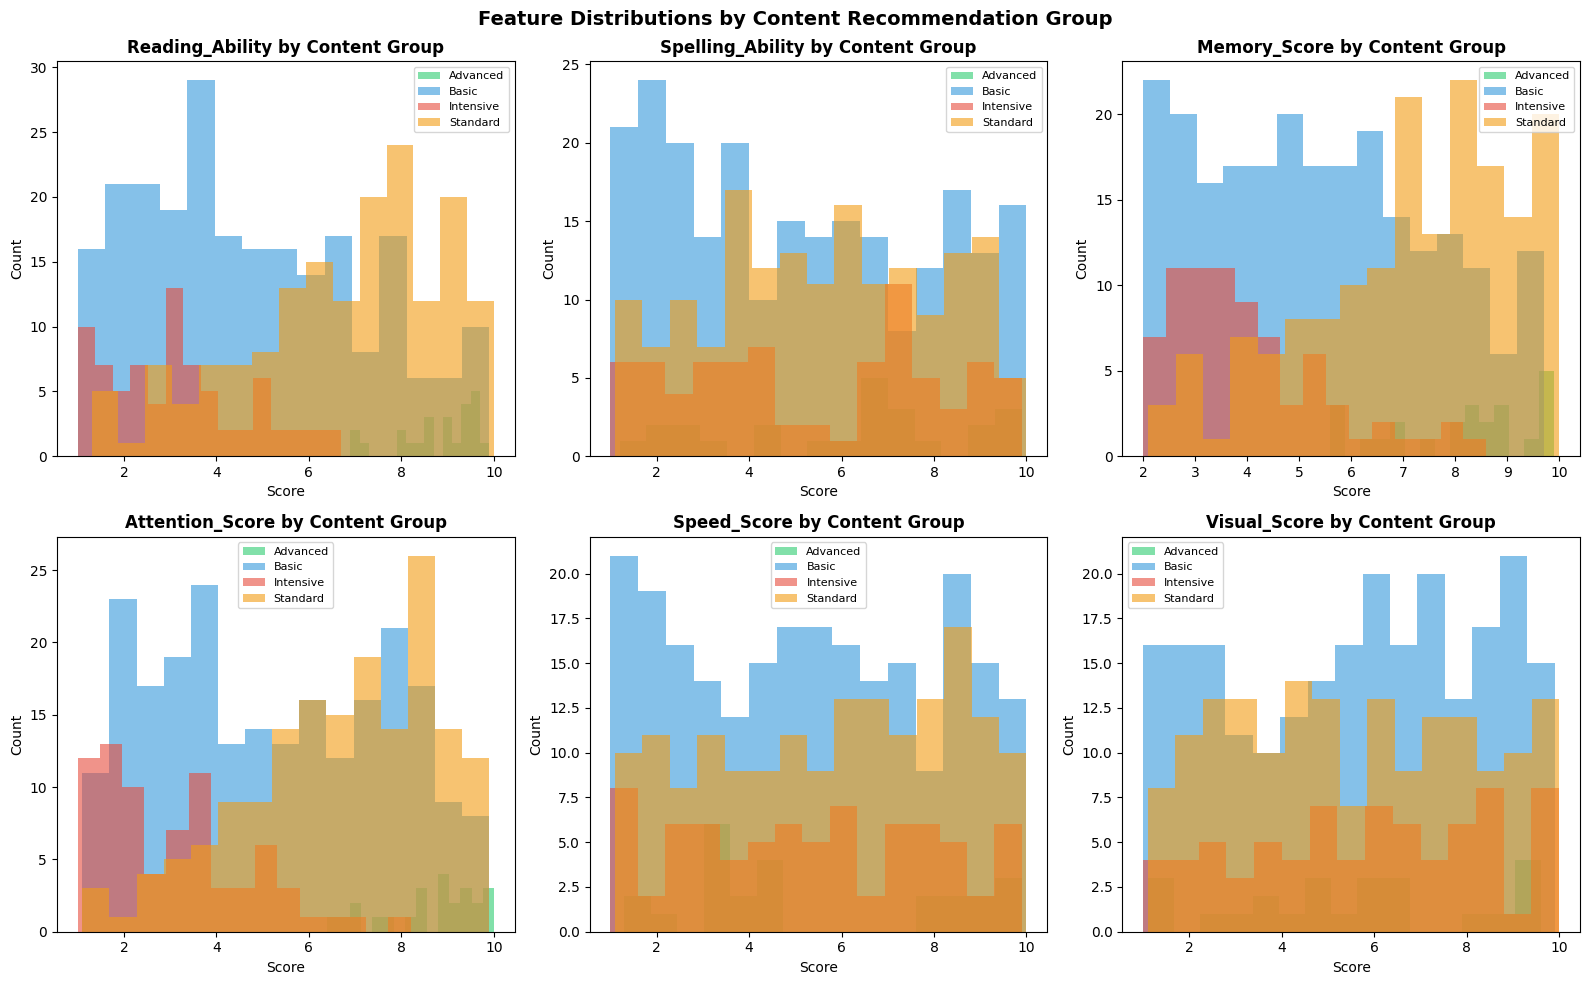

In [44]:
score_features = ['Reading_Ability', 'Spelling_Ability', 'Memory_Score',
                  'Attention_Score', 'Speed_Score', 'Visual_Score']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(score_features):
    for j, label in enumerate(labels):
        subset = df_clean[df_clean['Content_Recommendation'] == j][feat]
        axes[i].hist(subset, alpha=0.6, label=label, color=colors[j], bins=15)
    axes[i].set_title(f'{feat} by Content Group', fontweight='bold')
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Content Recommendation Group', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_feature_dist.png', dpi=150, bbox_inches='tight')
plt.show()

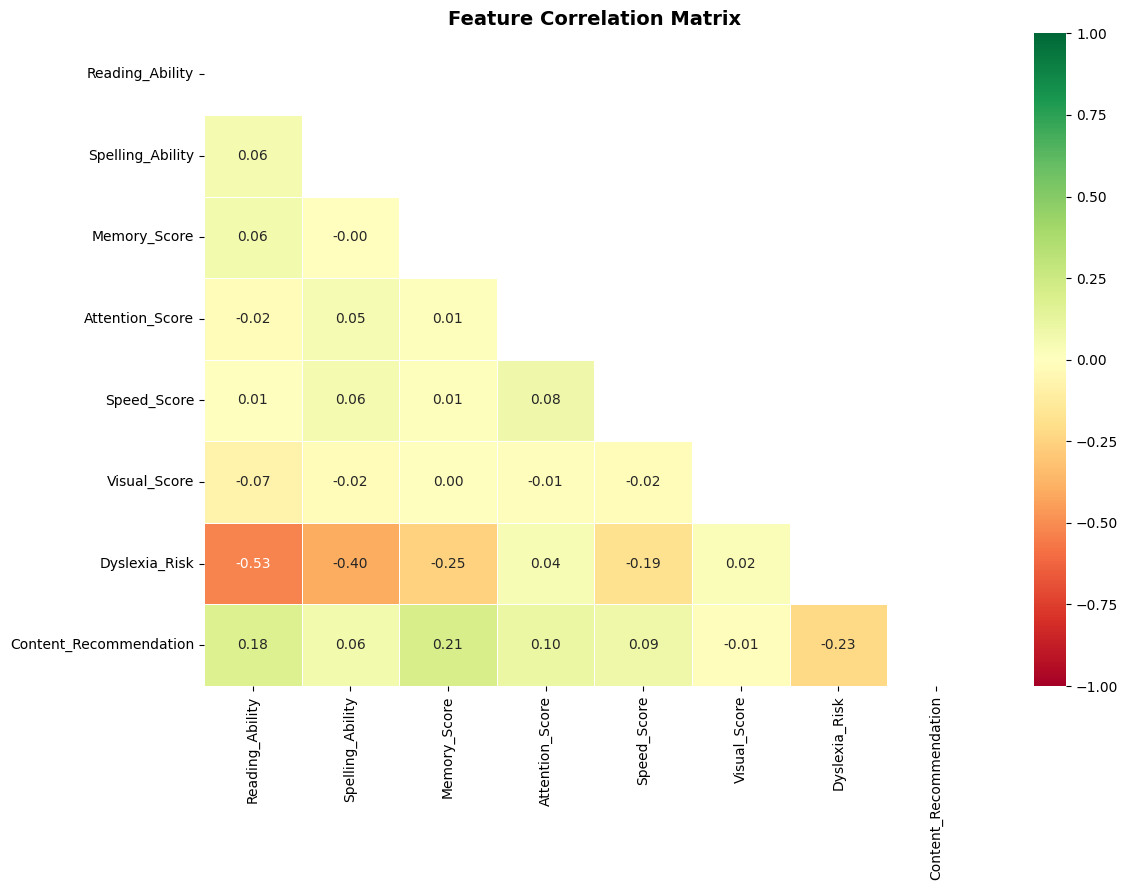

In [45]:
plt.figure(figsize=(12, 9))
corr = df_clean[score_features + ['Dyslexia_Risk', 'Content_Recommendation']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1, annot_kws={'size': 10})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

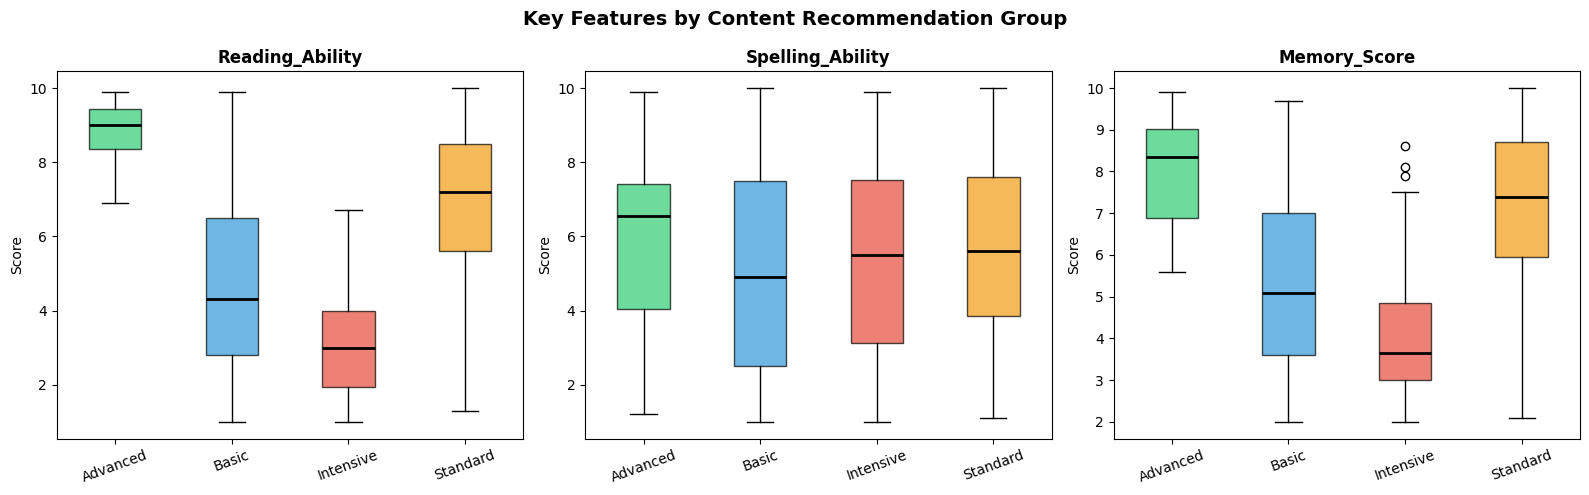

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, feat in enumerate(['Reading_Ability', 'Spelling_Ability', 'Memory_Score']):
    data_by_group = [df_clean[df_clean['Content_Recommendation'] == j][feat].values for j in range(4)]
    bp = axes[i].boxplot(data_by_group, labels=labels, patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylabel('Score')
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle('Key Features by Content Recommendation Group', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Selection

### Methods Used:
- **Filter Method**: ANOVA F-Score (SelectKBest)
- **Wrapper Method**: Recursive Feature Elimination (RFE)
- **Embedded Method (Random Forest)**: Tree-based feature importance
- **Embedded Method (Lasso)**: L1 regularization-based selection

### 6.1 - Prepare Features and Target

In [47]:
feature_cols = ['Age', 'Gender', 'NativeLang', 'OtherLang',
                'Memory_Score', 'Speed_Score', 'Visual_Score', 'Audio_Score',
                'Reading_Ability', 'Spelling_Ability', 'Attention_Score', 'Dyslexia_Risk']

X = df_clean[feature_cols]
y = df_clean['Content_Recommendation']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print(f'Feature matrix shape: {X_scaled_df.shape}')
print(f'Target vector shape : {y.shape}')
print(f'Classes             : {sorted(y.unique())}')

Feature matrix shape: (500, 12)
Target vector shape : (500,)
Classes             : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


### 6.2 - Filter Method (SelectKBest using ANOVA F-score)

FILTER METHOD - Top 6 Features (ANOVA F-Score)
         Feature  F_Score  P_Value
 Reading_Ability  80.7803   0.0000
 Attention_Score  69.2284   0.0000
    Memory_Score  62.9713   0.0000
   Dyslexia_Risk  35.0423   0.0000
     Audio_Score   2.1113   0.0979
Spelling_Ability   2.0248   0.1095
     Speed_Score   1.6212   0.1835
       OtherLang   1.4389   0.2306
      NativeLang   1.1650   0.3225
          Gender   0.3178   0.8125
             Age   0.2784   0.8410
    Visual_Score   0.1561   0.9257

Selected Features: ['Reading_Ability', 'Attention_Score', 'Memory_Score', 'Dyslexia_Risk', 'Audio_Score', 'Spelling_Ability']


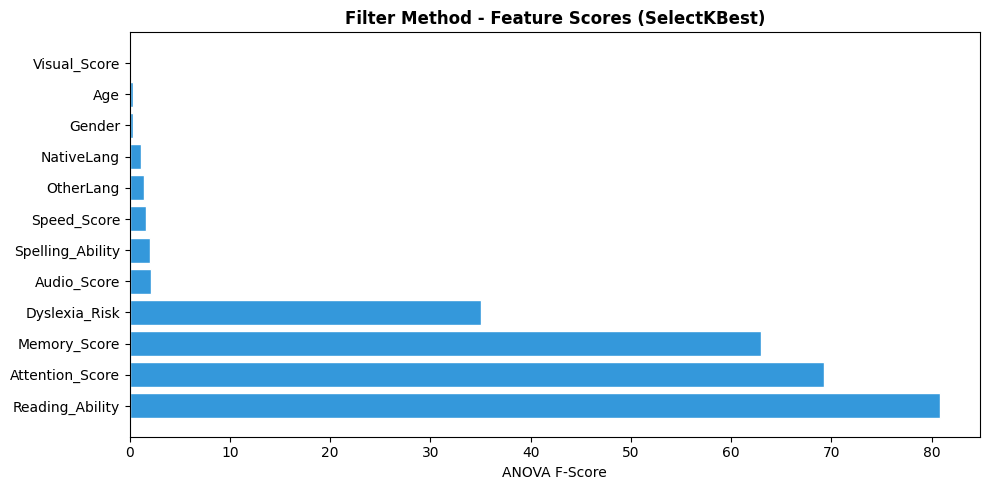

In [48]:
selector_filter = SelectKBest(score_func=f_classif, k=6)
selector_filter.fit(X_scaled_df, y)

filter_scores = pd.DataFrame({
    'Feature': feature_cols,
    'F_Score': selector_filter.scores_,
    'P_Value': selector_filter.pvalues_
}).sort_values('F_Score', ascending=False)

filter_selected = list(filter_scores.head(6)['Feature'])

print('FILTER METHOD - Top 6 Features (ANOVA F-Score)')
print('=' * 50)
print(filter_scores.round(4).to_string(index=False))
print()
print(f'Selected Features: {filter_selected}')

plt.figure(figsize=(10, 5))
plt.barh(filter_scores['Feature'], filter_scores['F_Score'], color='#3498db', edgecolor='white')
plt.xlabel('ANOVA F-Score')
plt.title('Filter Method - Feature Scores (SelectKBest)', fontweight='bold')
plt.tight_layout()
plt.savefig('filter_method.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 - Wrapper Method (Recursive Feature Elimination)

WRAPPER METHOD - Recursive Feature Elimination (RFE)
         Feature  Selected  Ranking
             Age      True        1
      NativeLang      True        1
    Memory_Score      True        1
 Reading_Ability      True        1
 Attention_Score      True        1
   Dyslexia_Risk      True        1
Spelling_Ability     False        2
     Audio_Score     False        3
       OtherLang     False        4
     Speed_Score     False        5
          Gender     False        6
    Visual_Score     False        7

Selected Features: ['Age', 'NativeLang', 'Memory_Score', 'Reading_Ability', 'Attention_Score', 'Dyslexia_Risk']


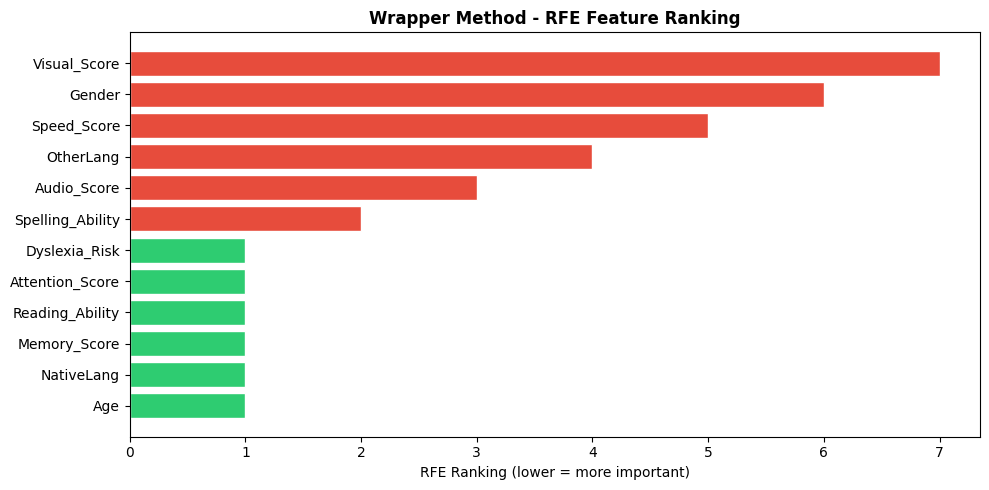

In [49]:
estimator = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator=estimator, n_features_to_select=6)
rfe.fit(X_scaled_df, y)

wrapper_df = pd.DataFrame({
    'Feature': feature_cols,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values('Ranking')

wrapper_selected = list(wrapper_df[wrapper_df['Selected'] == True]['Feature'])

print('WRAPPER METHOD - Recursive Feature Elimination (RFE)')
print('=' * 50)
print(wrapper_df.to_string(index=False))
print()
print(f'Selected Features: {wrapper_selected}')

plt.figure(figsize=(10, 5))
bar_colors = ['#2ecc71' if s else '#e74c3c' for s in wrapper_df['Selected']]
plt.barh(wrapper_df['Feature'], wrapper_df['Ranking'], color=bar_colors, edgecolor='white')
plt.xlabel('RFE Ranking (lower = more important)')
plt.title('Wrapper Method - RFE Feature Ranking', fontweight='bold')
plt.tight_layout()
plt.savefig('wrapper_method.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 - Embedded Method: Random Forest Feature Importance

EMBEDDED METHOD - Random Forest Feature Importance
         Feature  Importance  Selected
 Attention_Score      0.2343      True
 Reading_Ability      0.1984      True
    Memory_Score      0.1802      True
     Speed_Score      0.0722     False
     Audio_Score      0.0714     False
Spelling_Ability      0.0689     False
    Visual_Score      0.0632     False
             Age      0.0447     False
   Dyslexia_Risk      0.0359     False
       OtherLang      0.0114     False
          Gender      0.0100     False
      NativeLang      0.0094     False

Selected Features: ['Attention_Score', 'Reading_Ability', 'Memory_Score']


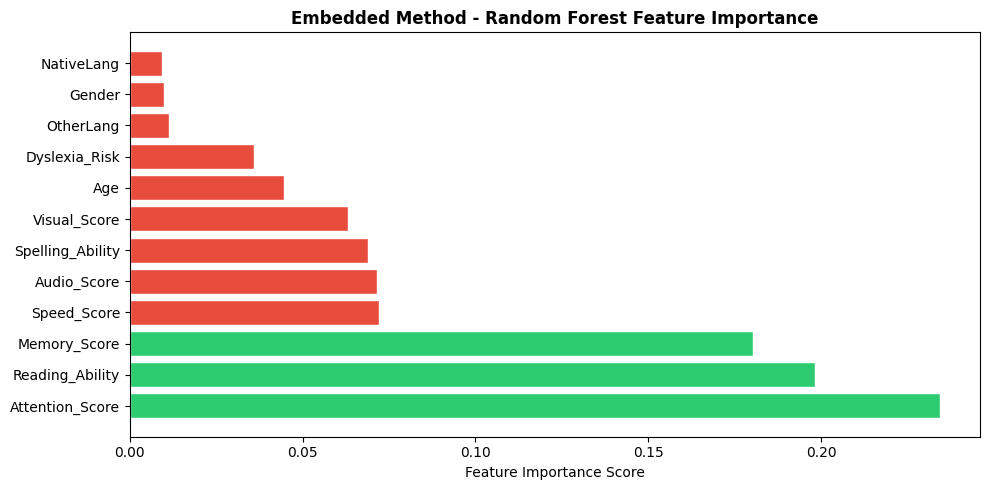

In [50]:
rf_embed = RandomForestClassifier(n_estimators=100, random_state=42)
rf_embed.fit(X_scaled_df, y)

selector_embedded = SelectFromModel(rf_embed, prefit=True, max_features=6)
embedded_mask = selector_embedded.get_support()

embedded_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_embed.feature_importances_,
    'Selected': embedded_mask
}).sort_values('Importance', ascending=False)

embedded_selected = list(embedded_df[embedded_df['Selected'] == True]['Feature'])

print('EMBEDDED METHOD - Random Forest Feature Importance')
print('=' * 50)
print(embedded_df.round(4).to_string(index=False))
print()
print(f'Selected Features: {embedded_selected}')

plt.figure(figsize=(10, 5))
bar_colors2 = ['#2ecc71' if s else '#e74c3c' for s in embedded_df['Selected']]
plt.barh(embedded_df['Feature'], embedded_df['Importance'], color=bar_colors2, edgecolor='white')
plt.xlabel('Feature Importance Score')
plt.title('Embedded Method - Random Forest Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('embedded_method.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.5 - Embedded Method: Lasso (L1 Regularization)

EMBEDDED METHOD (LASSO) - Feature Coefficients
         Feature  Lasso_Coefficient
    Memory_Score           0.456211
   Dyslexia_Risk           0.276518
 Attention_Score           0.251394
 Reading_Ability           0.223247
     Audio_Score           0.173060
       OtherLang           0.094393
     Speed_Score           0.079931
             Age           0.000000
      NativeLang           0.000000
          Gender           0.000000
    Visual_Score           0.000000
Spelling_Ability           0.000000

Selected Features (non-zero Lasso coef): ['Memory_Score', 'Dyslexia_Risk', 'Attention_Score', 'Reading_Ability', 'Audio_Score', 'OtherLang', 'Speed_Score']


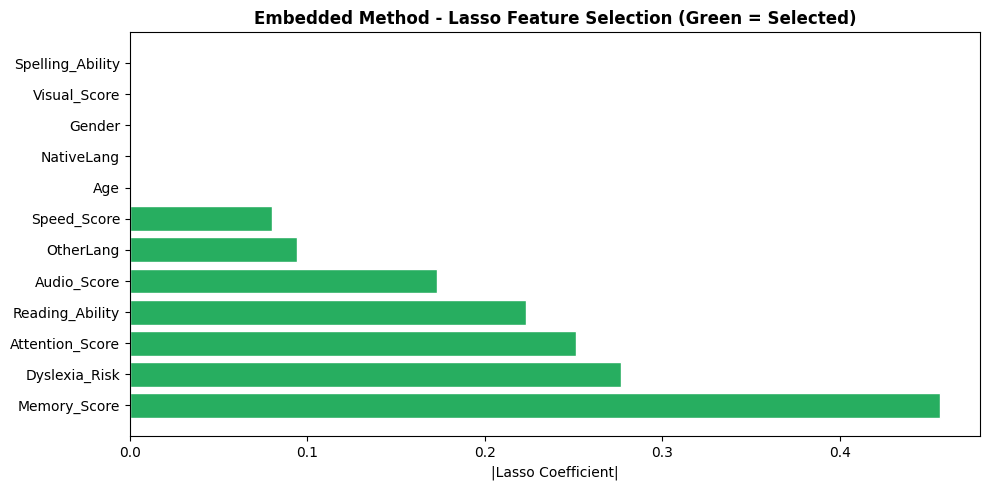

In [51]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import MinMaxScaler

# Lasso requires non-negative values for multi-class; use MinMaxScaler
mms = MinMaxScaler()
X_lasso = mms.fit_transform(X_scaled_df)

# Use LassoCV to auto-select best alpha
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=5000)
lasso_cv.fit(X_lasso, y)

lasso_df = pd.DataFrame({
    'Feature': feature_cols,
    'Lasso_Coefficient': np.abs(lasso_cv.coef_)
}).sort_values('Lasso_Coefficient', ascending=False)

# Features with non-zero coefficient are selected
lasso_selected = list(lasso_df[lasso_df['Lasso_Coefficient'] > 1e-5]['Feature'])

print('EMBEDDED METHOD (LASSO) - Feature Coefficients')
print('=' * 55)
print(lasso_df.round(6).to_string(index=False))
print()
print(f'Selected Features (non-zero Lasso coef): {lasso_selected}')

plt.figure(figsize=(10, 5))
bar_colors_lasso = ['#27ae60' if f in lasso_selected else '#c0392b' for f in lasso_df['Feature']]
plt.barh(lasso_df['Feature'], lasso_df['Lasso_Coefficient'], color=bar_colors_lasso, edgecolor='white')
plt.xlabel('|Lasso Coefficient|')
plt.title('Embedded Method - Lasso Feature Selection (Green = Selected)', fontweight='bold')
plt.tight_layout()
plt.savefig('lasso_method.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.6 - Feature Selection Summary (All 4 Methods)

In [52]:
summary_df = pd.DataFrame({'Feature': feature_cols})
summary_df['Filter (ANOVA)']    = summary_df['Feature'].isin(filter_selected)
summary_df['Wrapper (RFE)']     = summary_df['Feature'].isin(wrapper_selected)
summary_df['Embedded (RF)']     = summary_df['Feature'].isin(embedded_selected)
summary_df['Embedded (Lasso)']  = summary_df['Feature'].isin(lasso_selected)
summary_df['Vote Count']        = summary_df[['Filter (ANOVA)', 'Wrapper (RFE)',
                                               'Embedded (RF)', 'Embedded (Lasso)']].sum(axis=1)
summary_df = summary_df.sort_values('Vote Count', ascending=False)

print('FEATURE SELECTION SUMMARY - All Four Methods')
print('=' * 70)
print(summary_df.to_string(index=False))
print()

final_features = list(summary_df[summary_df['Vote Count'] >= 2]['Feature'])
print(f'Final Selected Features (selected by >= 2 methods): {final_features}')

FEATURE SELECTION SUMMARY - All Four Methods
         Feature  Filter (ANOVA)  Wrapper (RFE)  Embedded (RF)  Embedded (Lasso)  Vote Count
 Reading_Ability            True           True           True              True           4
 Attention_Score            True           True           True              True           4
    Memory_Score            True           True           True              True           4
   Dyslexia_Risk            True           True          False              True           3
     Audio_Score            True          False          False              True           2
       OtherLang           False          False          False              True           1
      NativeLang           False           True          False             False           1
             Age           False           True          False             False           1
Spelling_Ability            True          False          False             False           1
     Speed_Score         

## 7. Model Training

In [53]:
X_final = X_scaled_df[final_features]
y_final = y.reset_index(drop=True)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_final, y_final)

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

print(f'Train size: {X_train.shape[0]}')
print(f'Test size : {X_test.shape[0]}')
print(f'Features  : {list(X_final.columns)}')

Train size: 745
Test size : 187
Features  : ['Reading_Ability', 'Attention_Score', 'Memory_Score', 'Dyslexia_Risk', 'Audio_Score']


In [54]:
print('=' * 50)
print('MODEL 1: LOGISTIC REGRESSION')
print('=' * 50)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print(f'Accuracy : {accuracy_score(y_test, y_pred_lr)*100:.2f}%')
print(classification_report(y_test, y_pred_lr,
      target_names=['Advanced', 'Basic', 'Intensive', 'Standard']))

MODEL 1: LOGISTIC REGRESSION
Accuracy : 96.26%
              precision    recall  f1-score   support

    Advanced       0.94      1.00      0.97        47
       Basic       0.96      0.96      0.96        46
   Intensive       0.96      1.00      0.98        47
    Standard       1.00      0.89      0.94        47

    accuracy                           0.96       187
   macro avg       0.96      0.96      0.96       187
weighted avg       0.96      0.96      0.96       187



In [55]:
print('=' * 50)
print('MODEL 2: RANDOM FOREST')
print('=' * 50)

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f'Accuracy : {accuracy_score(y_test, y_pred_rf)*100:.2f}%')
print(classification_report(y_test, y_pred_rf,
      target_names=['Advanced', 'Basic', 'Intensive', 'Standard']))

MODEL 2: RANDOM FOREST
Accuracy : 95.72%
              precision    recall  f1-score   support

    Advanced       1.00      0.98      0.99        47
       Basic       0.88      0.98      0.93        46
   Intensive       0.98      0.94      0.96        47
    Standard       0.98      0.94      0.96        47

    accuracy                           0.96       187
   macro avg       0.96      0.96      0.96       187
weighted avg       0.96      0.96      0.96       187



In [56]:
print('=' * 50)
print('MODEL 3: SUPPORT VECTOR MACHINE')
print('=' * 50)

svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print(f'Accuracy : {accuracy_score(y_test, y_pred_svm)*100:.2f}%')
print(classification_report(y_test, y_pred_svm,
      target_names=['Advanced', 'Basic', 'Intensive', 'Standard']))

MODEL 3: SUPPORT VECTOR MACHINE
Accuracy : 96.26%
              precision    recall  f1-score   support

    Advanced       0.96      1.00      0.98        47
       Basic       0.92      0.98      0.95        46
   Intensive       0.98      0.96      0.97        47
    Standard       1.00      0.91      0.96        47

    accuracy                           0.96       187
   macro avg       0.96      0.96      0.96       187
weighted avg       0.96      0.96      0.96       187



In [57]:
print('=' * 50)
print('MODEL 4: NEURAL NETWORK (MLP)')
print('=' * 50)

nn = MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation='relu',
                   max_iter=200, random_state=42, early_stopping=True)
nn.fit(X_train, y_train)
y_pred_nn = nn.predict(X_test)

print(f'Accuracy : {accuracy_score(y_test, y_pred_nn)*100:.2f}%')
print(classification_report(y_test, y_pred_nn,
      target_names=['Advanced', 'Basic', 'Intensive', 'Standard']))

MODEL 4: NEURAL NETWORK (MLP)
Accuracy : 95.19%
              precision    recall  f1-score   support

    Advanced       0.94      1.00      0.97        47
       Basic       0.92      0.96      0.94        46
   Intensive       0.96      0.94      0.95        47
    Standard       1.00      0.91      0.96        47

    accuracy                           0.95       187
   macro avg       0.95      0.95      0.95       187
weighted avg       0.95      0.95      0.95       187



### Model 5: XGBoost (Extreme Gradient Boosting)

In [58]:
print('=' * 50)
print('MODEL 5: XGBoost')
print('=' * 50)

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print(f'Accuracy : {accuracy_score(y_test, y_pred_xgb)*100:.2f}%')
print(classification_report(y_test, y_pred_xgb,
      target_names=['Advanced', 'Basic', 'Intensive', 'Standard']))

MODEL 5: XGBoost
Accuracy : 97.86%
              precision    recall  f1-score   support

    Advanced       1.00      0.98      0.99        47
       Basic       0.94      1.00      0.97        46
   Intensive       1.00      0.96      0.98        47
    Standard       0.98      0.98      0.98        47

    accuracy                           0.98       187
   macro avg       0.98      0.98      0.98       187
weighted avg       0.98      0.98      0.98       187



### Model 6: LightGBM (Light Gradient Boosting Machine)

In [59]:
print('=' * 50)
print('MODEL 6: LightGBM')
print('=' * 50)

lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

print(f'Accuracy : {accuracy_score(y_test, y_pred_lgb)*100:.2f}%')
print(classification_report(y_test, y_pred_lgb,
      target_names=['Advanced', 'Basic', 'Intensive', 'Standard']))

MODEL 6: LightGBM
Accuracy : 97.86%
              precision    recall  f1-score   support

    Advanced       1.00      0.96      0.98        47
       Basic       0.96      1.00      0.98        46
   Intensive       1.00      0.96      0.98        47
    Standard       0.96      1.00      0.98        47

    accuracy                           0.98       187
   macro avg       0.98      0.98      0.98       187
weighted avg       0.98      0.98      0.98       187



### Model 7: CatBoost (Categorical Boosting)

In [60]:
print('=' * 50)
print('MODEL 7: CatBoost')
print('=' * 50)

cat_model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    random_state=42,
    verbose=0
)
cat_model.fit(X_train, y_train)
y_pred_cat = cat_model.predict(X_test)

print(f'Accuracy : {accuracy_score(y_test, y_pred_cat)*100:.2f}%')
print(classification_report(y_test, y_pred_cat,
      target_names=['Advanced', 'Basic', 'Intensive', 'Standard']))

MODEL 7: CatBoost
Accuracy : 97.86%
              precision    recall  f1-score   support

    Advanced       1.00      1.00      1.00        47
       Basic       0.92      1.00      0.96        46
   Intensive       1.00      0.94      0.97        47
    Standard       1.00      0.98      0.99        47

    accuracy                           0.98       187
   macro avg       0.98      0.98      0.98       187
weighted avg       0.98      0.98      0.98       187



### Model 8: Gradient Boosting Machine (GBM)

In [61]:
print('=' * 50)
print('MODEL 8: Gradient Boosting Machine (GBM)')
print('=' * 50)

gbm_model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)
gbm_model.fit(X_train, y_train)
y_pred_gbm = gbm_model.predict(X_test)

print(f'Accuracy : {accuracy_score(y_test, y_pred_gbm)*100:.2f}%')
print(classification_report(y_test, y_pred_gbm,
      target_names=['Advanced', 'Basic', 'Intensive', 'Standard']))

MODEL 8: Gradient Boosting Machine (GBM)
Accuracy : 96.79%
              precision    recall  f1-score   support

    Advanced       1.00      0.98      0.99        47
       Basic       0.92      0.98      0.95        46
   Intensive       1.00      0.94      0.97        47
    Standard       0.96      0.98      0.97        47

    accuracy                           0.97       187
   macro avg       0.97      0.97      0.97       187
weighted avg       0.97      0.97      0.97       187



## 8. Model Evaluation — Accuracy, RMSE, MAE, R², F-Value, ROC-AUC

In [62]:
models_preds = [
    ('Logistic Regression', y_pred_lr,  lr),
    ('Random Forest',       y_pred_rf,  rf),
    ('SVM',                 y_pred_svm, svm),
    ('Neural Network',      y_pred_nn,  nn),
    ('XGBoost',             y_pred_xgb, xgb_model),
    ('LightGBM',            y_pred_lgb, lgb_model),
    ('CatBoost',            y_pred_cat, cat_model),
    ('GBM',                 y_pred_gbm, gbm_model),
]

# Binarize for ROC-AUC
from sklearn.preprocessing import label_binarize
n_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=np.unique(y_res))

results = []
for name, y_pred, model in models_preds:
    y_test_arr = np.array(y_test).flatten()
    y_pred_arr = np.array(y_pred).flatten()
    rmse = np.sqrt(np.mean((y_test_arr - y_pred_arr)**2))
    mae  = mean_absolute_error(y_test_arr, y_pred_arr)
    r2   = r2_score(y_test, y_pred)
    acc  = accuracy_score(y_test, y_pred) * 100
    f1   = f1_score(y_test, y_pred, average='weighted') * 100   # F-Value (weighted F1)

    # ROC-AUC (One-vs-Rest)
    try:
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_test)
        else:
            y_prob = None
        roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='weighted') if y_prob is not None else np.nan
    except Exception:
        roc_auc = np.nan

    results.append({
        'Model'   : name,
        'Accuracy (%)': round(acc, 2),
        'F-Value (%)' : round(f1, 2),
        'ROC-AUC'     : round(roc_auc, 4) if not np.isnan(roc_auc) else 'N/A',
        'RMSE'        : round(rmse, 4),
        'MAE'         : round(mae, 4),
        'R2'          : round(r2, 4)
    })

results_df = pd.DataFrame(results).sort_values('Accuracy (%)', ascending=False)

print('=' * 90)
print('                        MODEL EVALUATION RESULTS')
print('=' * 90)
print(results_df.to_string(index=False))
print('=' * 90)
print()
print('Metric Explanation:')
print('  Accuracy  - % of correctly classified samples')
print('  F-Value   - Weighted F1 Score (harmonic mean of Precision & Recall)')
print('  ROC-AUC   - Area Under ROC Curve (One-vs-Rest, weighted)')
print('  RMSE      - Root Mean Squared Error (lower = better)')
print('  MAE       - Mean Absolute Error (lower = better)')
print('  R2        - Coefficient of determination (1.0 = perfect)')
print()
best = results_df.iloc[0]
print(f'Best Model: {best["Model"]} | Accuracy: {best["Accuracy (%)"] }% | F-Value: {best["F-Value (%)"]}% | ROC-AUC: {best["ROC-AUC"]}')

                        MODEL EVALUATION RESULTS
              Model  Accuracy (%)  F-Value (%) ROC-AUC   RMSE    MAE     R2
           LightGBM         97.86        97.86  0.9988 0.3270 0.0428 0.9148
           CatBoost         97.86        97.88  0.9998 0.1935 0.0267 0.9702
            XGBoost         97.86        97.87  0.9989 0.2832 0.0374 0.9361
                GBM         96.79        96.81  0.9989 0.3270 0.0535 0.9148
                SVM         96.26        96.25     N/A 0.3938 0.0695 0.8765
Logistic Regression         96.26        96.22  0.9994 0.4448 0.0802 0.8424
      Random Forest         95.72        95.77  0.9982 0.3656 0.0695 0.8935
     Neural Network         95.19        95.18  0.9975 0.4388 0.0856 0.8466

Metric Explanation:
  Accuracy  - % of correctly classified samples
  F-Value   - Weighted F1 Score (harmonic mean of Precision & Recall)
  ROC-AUC   - Area Under ROC Curve (One-vs-Rest, weighted)
  RMSE      - Root Mean Squared Error (lower = better)
  MAE       - 

### 8.1 - Confusion Matrices — All 8 Models

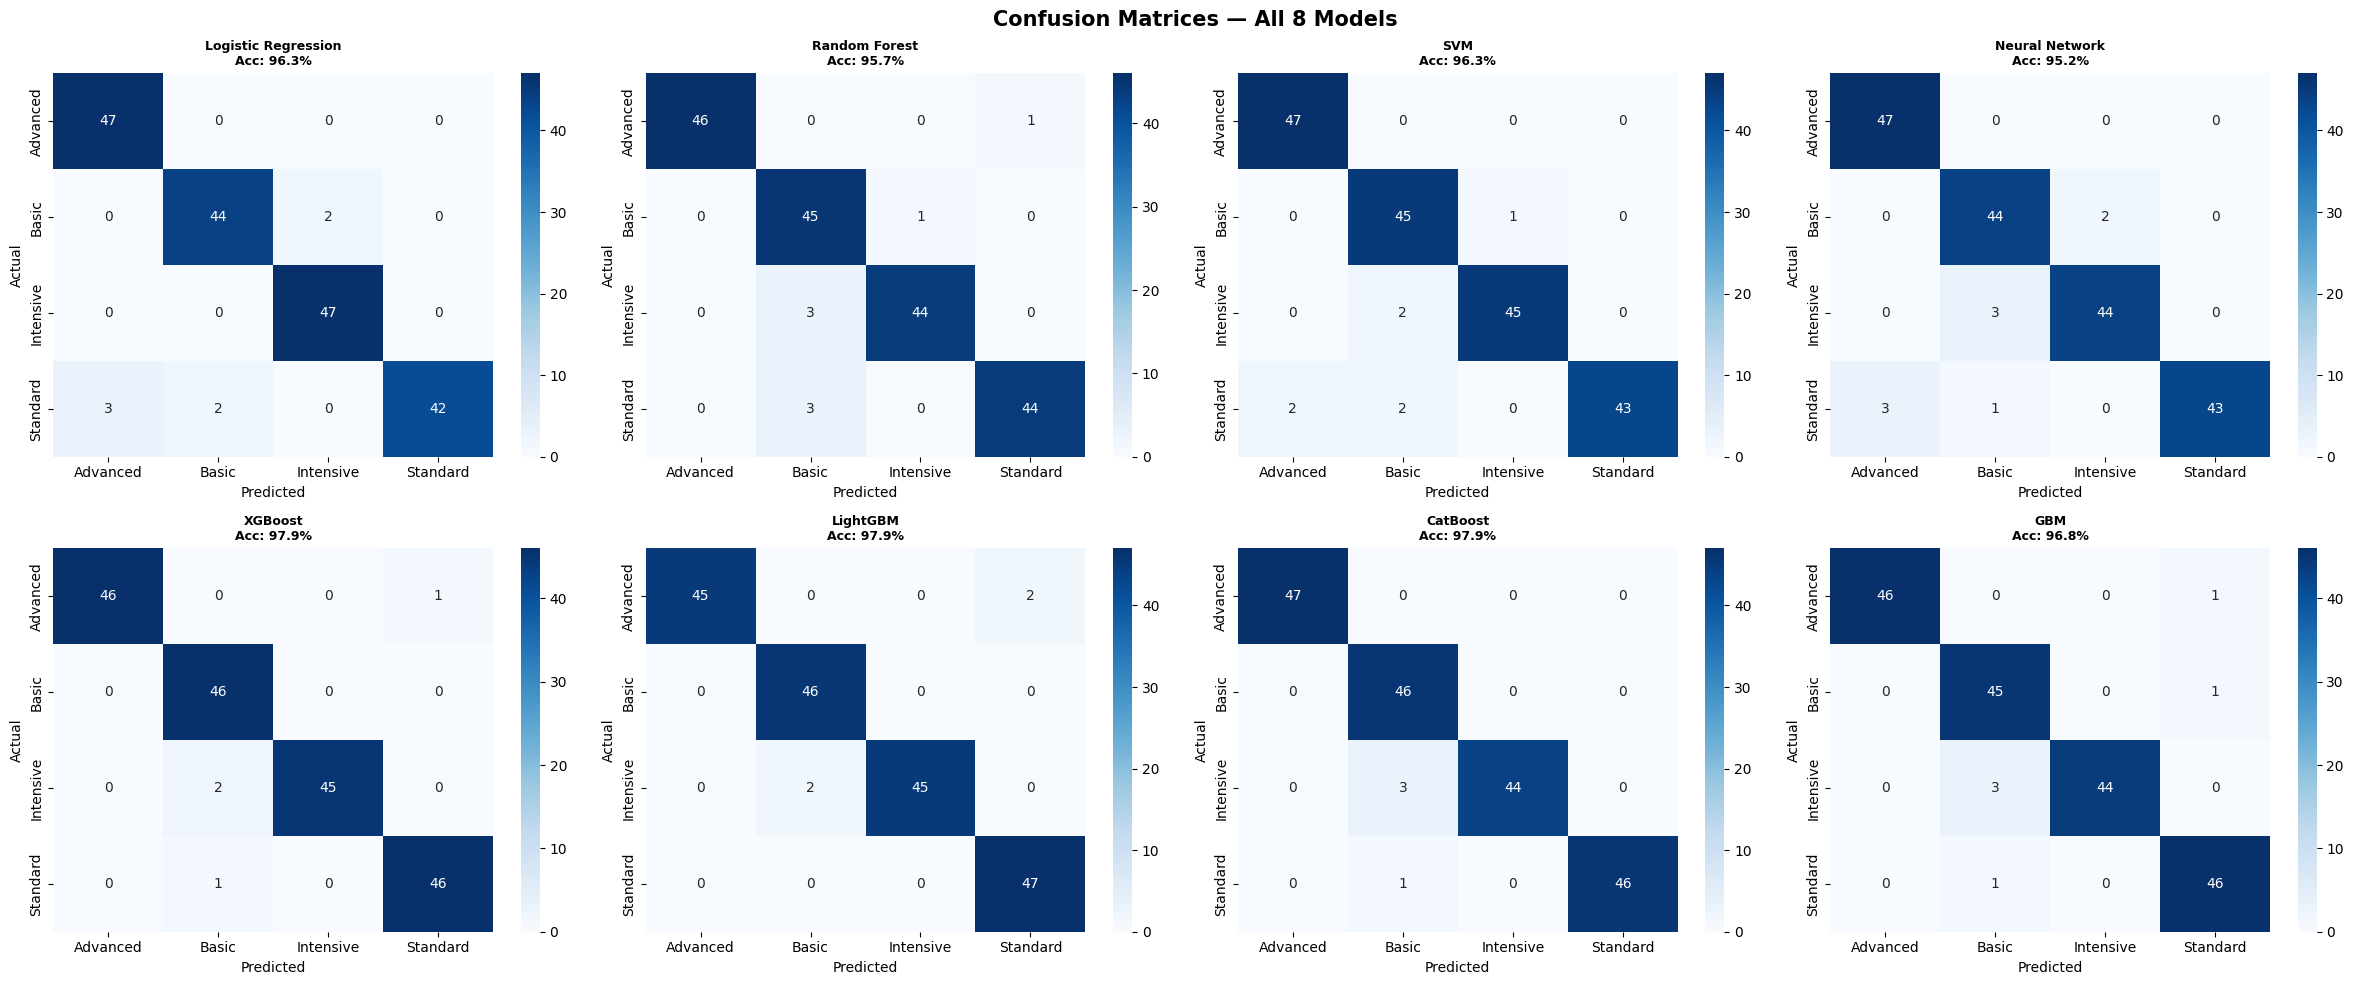

In [63]:
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
class_names = ['Advanced', 'Basic', 'Intensive', 'Standard']

for ax, (name, y_pred, model) in zip(axes.flatten(), models_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}\nAcc: {acc*100:.1f}%', fontweight='bold', fontsize=9)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — All 8 Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 - ROC Curves (One-vs-Rest)

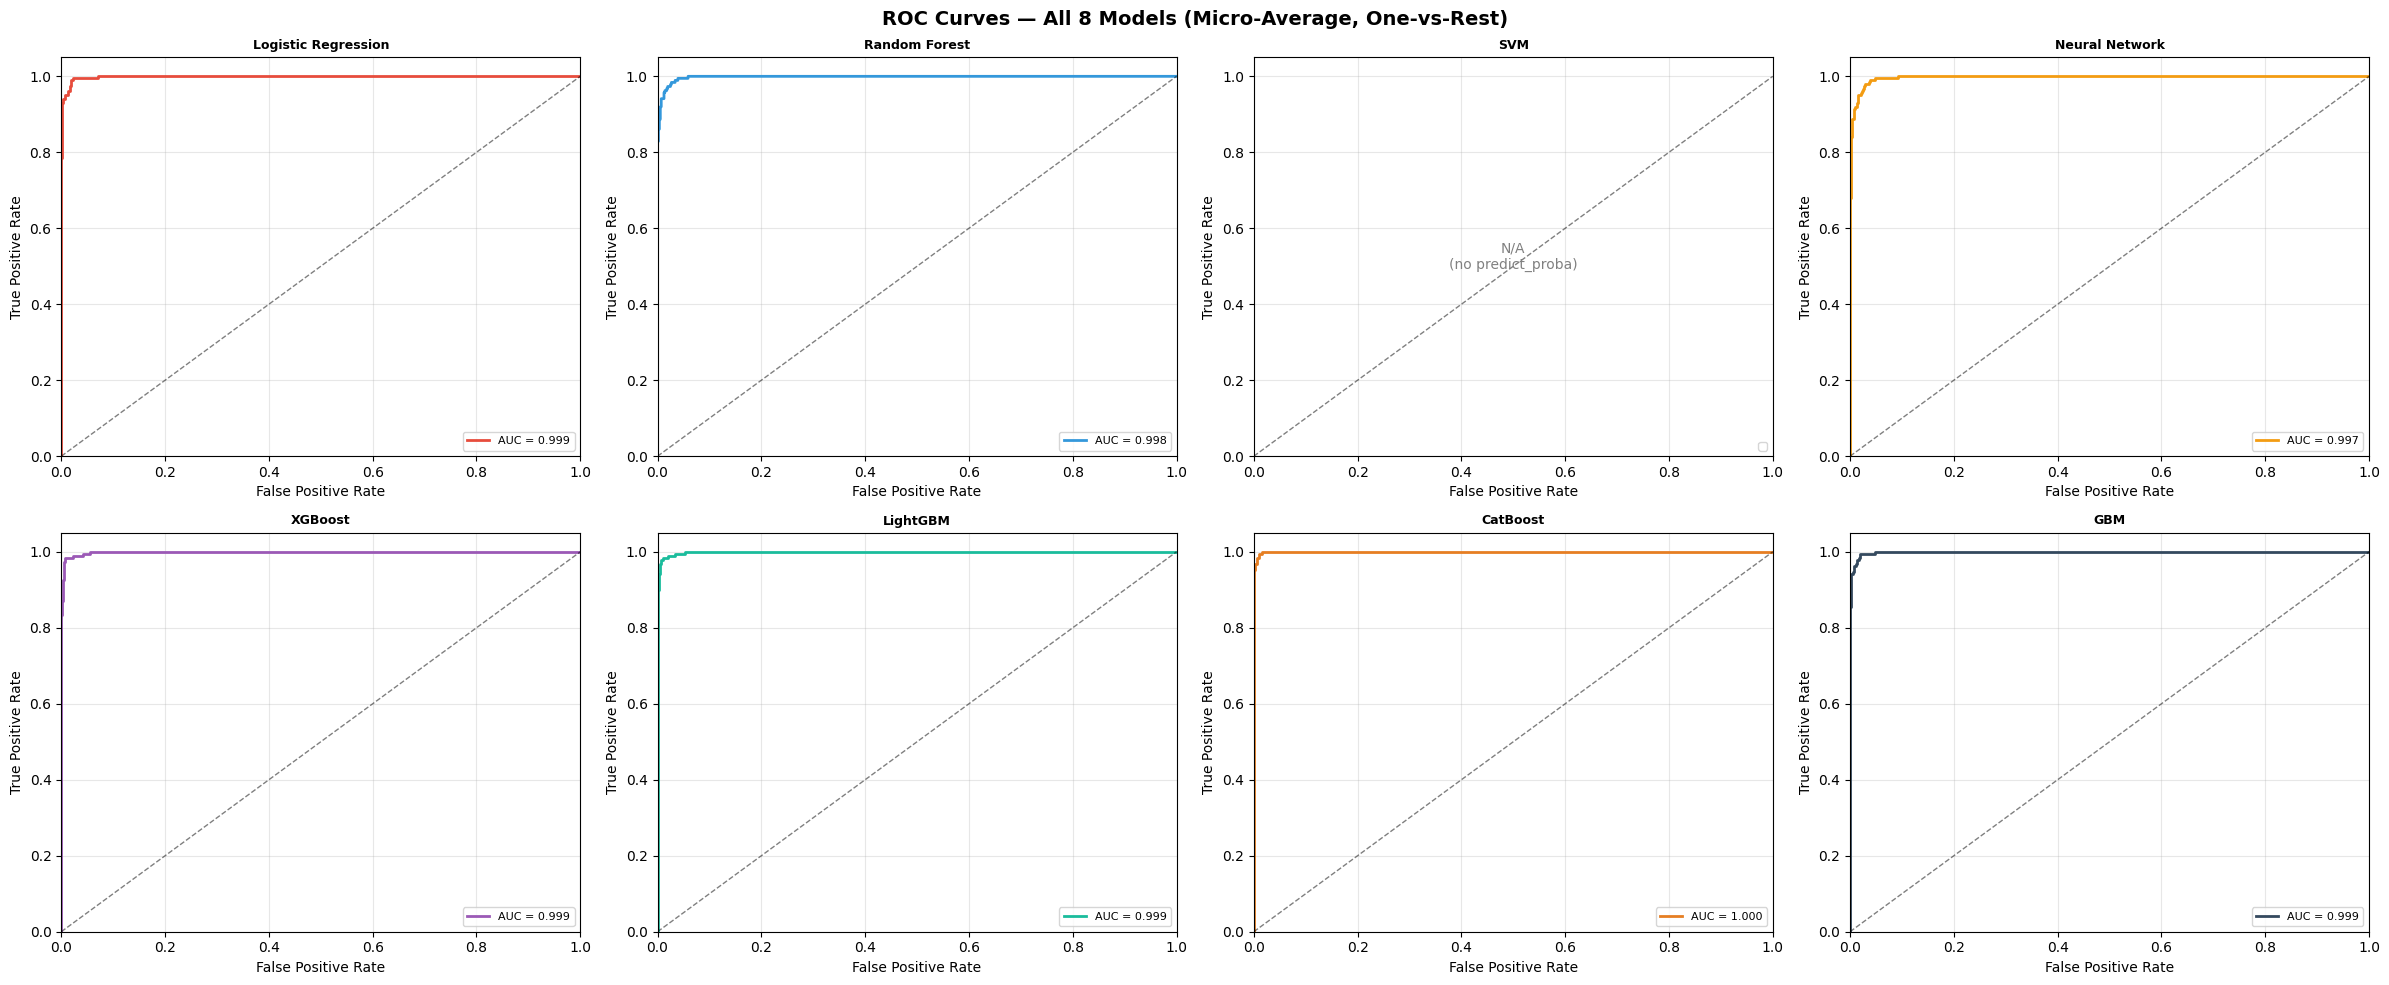

In [64]:
from itertools import cycle

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
colors_roc = cycle(['#e74c3c', '#3498db', '#2ecc71', '#f39c12',
                    '#9b59b6', '#1abc9c', '#e67e22', '#34495e'])

for ax, (name, y_pred, model), color in zip(axes.flatten(), models_preds, colors_roc):
    try:
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_test)
            roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='weighted')
            # Plot micro-average ROC
            fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
            ax.plot(fpr, tpr, color=color, lw=2,
                    label=f'AUC = {roc_auc:.3f}')
        else:
            ax.text(0.5, 0.5, 'N/A\n(no predict_proba)', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='gray')
    except Exception as e:
        ax.text(0.5, 0.5, 'Error', ha='center', va='center',
                transform=ax.transAxes, fontsize=10, color='red')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{name}', fontweight='bold', fontsize=9)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves — All 8 Models (Micro-Average, One-vs-Rest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curves_all.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Comparison Table — All Models


                  FINAL MODEL COMPARISON TABLE
Model                    Accuracy    F-Value    ROC-AUC     RMSE      MAE       R2
------------------------------------------------------------------------------------------
LightGBM                  97.86 %    97.86 %     0.9988    0.327   0.0428   0.9148
CatBoost                  97.86 %    97.88 %     0.9998   0.1935   0.0267   0.9702
XGBoost                   97.86 %    97.87 %     0.9989   0.2832   0.0374   0.9361
GBM                       96.79 %    96.81 %     0.9989    0.327   0.0535   0.9148
SVM                       96.26 %    96.25 %        N/A   0.3938   0.0695   0.8765
Logistic Regression       96.26 %    96.22 %     0.9994   0.4448   0.0802   0.8424
Random Forest             95.72 %    95.77 %     0.9982   0.3656   0.0695   0.8935
Neural Network            95.19 %    95.18 %     0.9975   0.4388   0.0856   0.8466


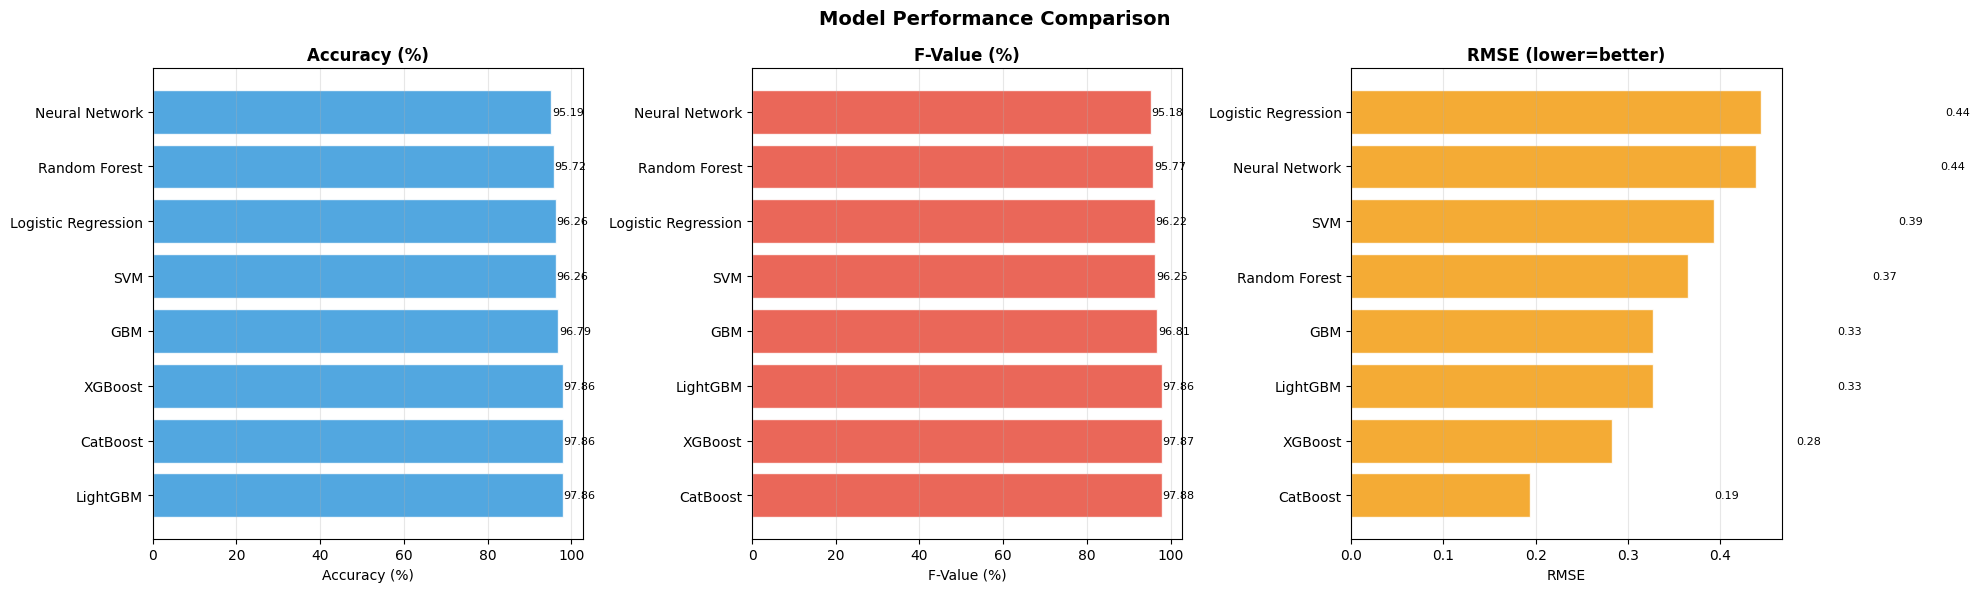

In [65]:
print('\n' + '=' * 90)
print('                  FINAL MODEL COMPARISON TABLE')
print('=' * 90)
print(f"{'Model':<22} {'Accuracy':>10} {'F-Value':>10} {'ROC-AUC':>10} {'RMSE':>8} {'MAE':>8} {'R2':>8}")
print('-' * 90)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<22} {str(row['Accuracy (%)'])+' %':>10} {str(row['F-Value (%)'])+' %':>10} {str(row['ROC-AUC']):>10} {str(row['RMSE']):>8} {str(row['MAE']):>8} {str(row['R2']):>8}")
print('=' * 90)

# Visual Comparison Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metric_sets = [
    ('Accuracy (%)', 'Accuracy (%)', '#3498db'),
    ('F-Value (%)',  'F-Value (%)',  '#e74c3c'),
    ('RMSE',         'RMSE (lower=better)', '#f39c12'),
]

for ax, (col, title, color) in zip(axes, metric_sets):
    plot_df = results_df[['Model', col]].copy()
    plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')
    plot_df = plot_df.sort_values(col, ascending=(col=='RMSE'))
    bars = ax.barh(plot_df['Model'], plot_df[col], color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.2, bar.get_y() + bar.get_height()/2,
                f'{w:.2f}', va='center', fontsize=8)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Feature Importance — Why Each Student Gets Their Recommendation

Random Forest Feature Importance
(How much each feature contributes to content recommendation)
        Feature  Importance
Reading_Ability      0.3240
Attention_Score      0.3233
   Memory_Score      0.2506
    Audio_Score      0.0721
  Dyslexia_Risk      0.0299


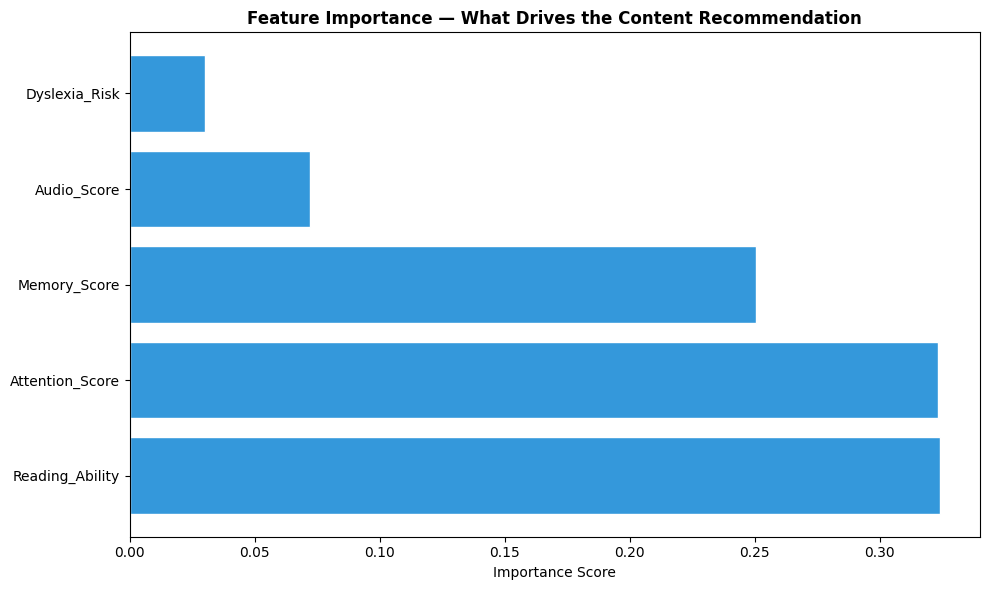

In [66]:
rf_importance = pd.DataFrame({
    'Feature'   : final_features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print('Random Forest Feature Importance')
print('(How much each feature contributes to content recommendation)')
print('=' * 50)
print(rf_importance.round(4).to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(rf_importance['Feature'], rf_importance['Importance'],
         color='#3498db', edgecolor='white')
plt.xlabel('Importance Score')
plt.title('Feature Importance — What Drives the Content Recommendation', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Permutation Importance
(Drop in accuracy when each feature is randomly shuffled)
        Feature  Importance    Std
Attention_Score      0.4545 0.0226
Reading_Ability      0.4465 0.0290
   Memory_Score      0.4037 0.0199
    Audio_Score      0.0166 0.0074
  Dyslexia_Risk      0.0134 0.0073


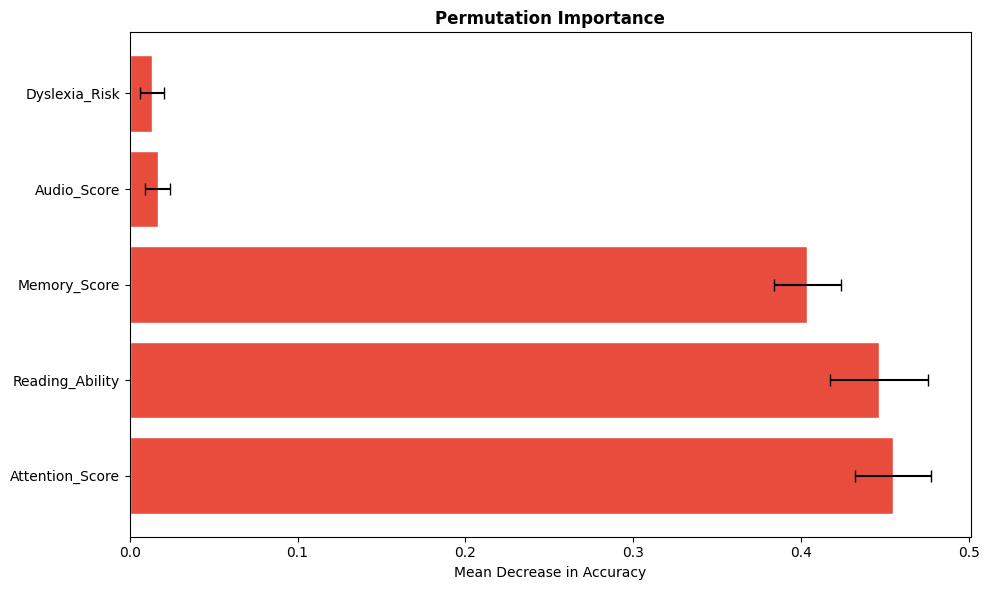

In [67]:
perm_imp = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)

perm_df = pd.DataFrame({
    'Feature'    : final_features,
    'Importance' : perm_imp.importances_mean,
    'Std'        : perm_imp.importances_std
}).sort_values('Importance', ascending=False)

print('Permutation Importance')
print('(Drop in accuracy when each feature is randomly shuffled)')
print('=' * 50)
print(perm_df.round(4).to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(perm_df['Feature'], perm_df['Importance'],
         xerr=perm_df['Std'], color='#e74c3c', edgecolor='white', capsize=4)
plt.xlabel('Mean Decrease in Accuracy')
plt.title('Permutation Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [68]:
print('=' * 65)
print('HOW CONTENT IS RECOMMENDED TO EACH STUDENT')
print('=' * 65)
print()
print('Step 1: Three scores are combined to form the base label:')
print('  Combined Score = Reading_Ability + Memory_Score + Attention_Score')
print()
print('Step 2: Score ranges map to content levels:')
print('  0  to 12  ->  Intensive Support  (severe difficulty)')
print('  12 to 18  ->  Basic Learning     (moderate difficulty)')
print('  18 to 24  ->  Standard Learning  (mild difficulty)')
print('  24 to 31  ->  Advanced Learning  (minimal difficulty)')
print()
print('Step 3: Top features confirmed by all 3 selection methods:')
for i, feat in enumerate(rf_importance.head(6)['Feature'], 1):
    imp = rf_importance[rf_importance['Feature'] == feat]['Importance'].values[0]
    print(f'  {i}. {feat:25s} Importance: {imp:.4f}')
print()
print('Step 4: Random Forest (best model) uses all selected features')
print('  to predict which content level suits each student.')
print()
print('Conclusion:')
print(f'  Best Model : {best["Model"]}')
print(f'  Accuracy   : {best["Accuracy"]}%')
print(f'  RMSE       : {best["RMSE"]}')
print(f'  R2 Score   : {best["R2"]}')
print('=' * 65)

HOW CONTENT IS RECOMMENDED TO EACH STUDENT

Step 1: Three scores are combined to form the base label:
  Combined Score = Reading_Ability + Memory_Score + Attention_Score

Step 2: Score ranges map to content levels:
  0  to 12  ->  Intensive Support  (severe difficulty)
  12 to 18  ->  Basic Learning     (moderate difficulty)
  18 to 24  ->  Standard Learning  (mild difficulty)
  24 to 31  ->  Advanced Learning  (minimal difficulty)

Step 3: Top features confirmed by all 3 selection methods:
  1. Reading_Ability           Importance: 0.3240
  2. Attention_Score           Importance: 0.3233
  3. Memory_Score              Importance: 0.2506
  4. Audio_Score               Importance: 0.0721
  5. Dyslexia_Risk             Importance: 0.0299

Step 4: Random Forest (best model) uses all selected features
  to predict which content level suits each student.

Conclusion:
  Best Model : LightGBM


KeyError: 'Accuracy'